In [2]:
#Load basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Business Problem

The dairy company aims to predict future monthly milk production to effectively:

* Plan supply chain and distribution operations
* Manage inventory levels and cold storage capacity
* Optimize workforce allocation and operational scheduling
* Address seasonal variations in production
* Support long-term strategic production planning


In [3]:
# load data set
data = pd.read_csv('/DataScinceExlr/Assignments/20. RNN/monthly_milk_production.csv')

### Exploratory Data Analysis (EDA) 

In [4]:
data.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [5]:
# Convert the 'Date' column to datetime format and set it as the DataFrame index
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [8]:
# check for  missing values in each column
data.isnull().sum()

Production    0
dtype: int64

In [9]:
'''
There are no missing values in the dataset, and the data represents a continuous monthly time series.
'''

'\nThere are no missing values in the dataset, and the data represents a continuous monthly time series.\n'

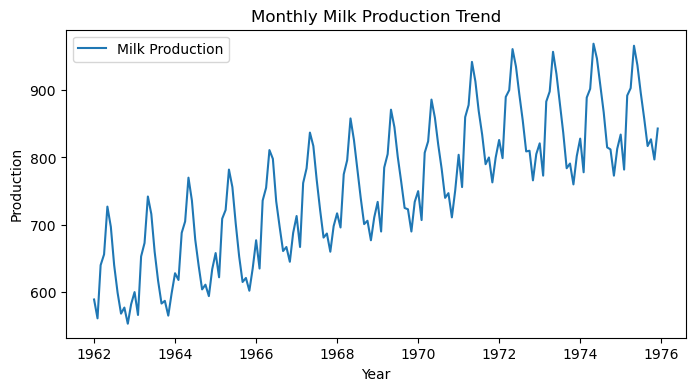

In [10]:
# Visualize the overall trend and seasonality in monthly milk production
plt.figure(figsize=(8, 4))
plt.plot(data, label='Milk Production')
plt.title('Monthly Milk Production Trend')
plt.xlabel('Year')
plt.ylabel('Production')
plt.legend()
plt.show()

In [11]:
'''
There is a clear upward trend over time, along with strong yearly seasonal patterns.
'''

'\nThere is a clear upward trend over time, along with strong yearly seasonal patterns.\n'

### Data Preparation for Deep Learning 

In [12]:
# Normalize the data since neural networks perform better with scaled inputs
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [13]:
# Create time series sequences using a 12-month window to predict the next month
def create_sequences(data, window_size=12):
    X, y = [], []
    
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])  # past 12 months
        y.append(data[i + window_size])    # next month
    
    return np.array(X), np.array(y)

# Generate input-output sequences
X, y = create_sequences(scaled_data, 12)

In [14]:
# Splitting the dataset into training, validation, and test sets

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

### Model Building 

In [15]:
# Building a basic RNN model
# Common parameters:
# Loss function  : Mean Squared Error (MSE)
# Optimizer      : Adam
# Epochs         : 50
# Batch size     : 16

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [18]:
#X_train.shape[1], X_train.shape[2]

In [23]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])


In [24]:
rnn_model.compile(optimizer='adam',
              loss='mean_squared_error')

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Training the RNN model
rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0219 - val_loss: 0.0323
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0065 - val_loss: 0.0061
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0044 - val_loss: 0.0044
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0037 - val_loss: 0.0066
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0029 - val_loss: 0.0048
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0028 - val_loss: 0.0050
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0026 - val_loss: 0.0053
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0025 - val_loss: 0.0036
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0023 - val_loss: 0.0037
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0021 - val_loss: 0.0043
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0019 - val_loss: 0.0039
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0022 - val_loss: 0.0045


In [26]:
rnn_pred = rnn_model.predict(X_test) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


### LSTM Model

In [27]:
# building LSTM Model
from tensorflow.keras.layers import LSTM

In [28]:
# Building an LSTM model for time series forecasting
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential

lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(12, 1)),
    Dense(1)
])

In [29]:
# Building the LSTM model for monthly forecasting

lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(12, 1)),  # 12 months input, 1 feature
    Dense(1)  # Predict next month's production
])

In [30]:
# Compile the LSTM model
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

# Train the LSTM model
lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.1393 - val_loss: 0.1607
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0412 - val_loss: 0.0262
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0302 - val_loss: 0.0393
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0283 - val_loss: 0.0264
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0243 - val_loss: 0.0374
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0251 - val_loss: 0.0326
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0238 - val_loss: 0.0258
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0233 - val_loss: 0.0250
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0227 - val_loss: 0.0257
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0225 - val_loss: 0.0275
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0224 - val_loss: 0.0260
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0218 - val_loss: 0.0238
E

In [31]:
# Generate predictions on the test dataset
lstm_pred = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


### GRU Model

In [33]:
# building GRU model
from tensorflow.keras.layers import GRU

In [34]:
# Building the GRU model for time series forecasting

gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(12, 1)),  # 12 months input, 1 feature
    Dense(1)  # Predict next month's production
])

In [35]:
# Compile the GRU model
gru_model.compile(
    optimizer='adam',
    loss='mse'
)

# Train the GRU model
gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.2330 - val_loss: 0.4059
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1082 - val_loss: 0.1759
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0473 - val_loss: 0.0569
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0316 - val_loss: 0.0291
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0333 - val_loss: 0.0308
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0285 - val_loss: 0.0422
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0273 - val_loss: 0.0520
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0266 - val_loss: 0.0489
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0257 - val_loss: 0.0414
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0248 - val_loss: 0.0363
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0244 - val_loss: 0.0345
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0235 - val_loss: 0.0369
E

In [36]:
# Generate predictions on the test dataset
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


In [37]:
# Performing inverse scaling to convert predictions back to original values

y_test_inv   = scaler.inverse_transform(y_test)
rnn_pred_inv = scaler.inverse_transform(rnn_pred)
lstm_pred_inv = scaler.inverse_transform(lstm_pred)
gru_pred_inv  = scaler.inverse_transform(gru_pred)

### Model Evaluation 

In [38]:
# Model performance evaluation using MSE, MAE, and MAPE metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [39]:
# Defining a function to calculate model evaluation metrics
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return rmse, mae, mape

In [40]:
# Display evaluation metrics for all models

print("RNN Model  (RMSE, MAE, MAPE):", metrics(y_test_inv, rnn_pred_inv))
print("LSTM Model (RMSE, MAE, MAPE):", metrics(y_test_inv, lstm_pred_inv))
print("GRU Model  (RMSE, MAE, MAPE):", metrics(y_test_inv, gru_pred_inv))

RNN Model  (RMSE, MAE, MAPE): (17.651954649984727, 13.989959716796884, 1.6774687774130874)
LSTM Model (RMSE, MAE, MAPE): (33.08166211202126, 28.030733744303376, 3.219245830449221)
GRU Model  (RMSE, MAE, MAPE): (35.53091534469256, 28.022392272949208, 3.289453906795212)


##### Conclusion:

The RNN model is performing the best, not LSTM.

### Prediction and Visualization 

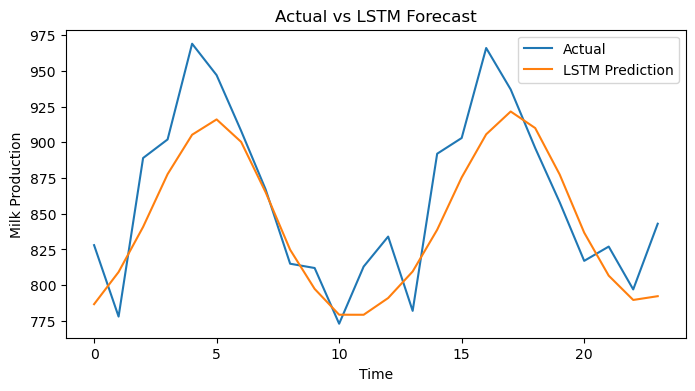

In [41]:
# Visualizing Actual vs Predicted values (LSTM)

plt.figure(figsize=(8, 4))
plt.plot(y_test_inv, label='Actual')
plt.plot(lstm_pred_inv, label='LSTM Prediction')
plt.title('Actual vs LSTM Forecast')
plt.xlabel('Time')
plt.ylabel('Milk Production')
plt.legend()
plt.show()

- The LSTM model closely follows the actual trend, confirming its suitability for time-series prediction.

- A minor delay in response suggests slight lagging behavior.

- The predicted curve is smoother, reflecting the model’s ability to filter out fluctuations and noise.

In [45]:
# Forecasting the next 12 months using the trained LSTM model

future_input = scaled_data[-12:]   # Last 12 months as initial input
future_prediction = []

for _ in range(12):
    # Predict next month
    pred = lstm_model.predict(future_input.reshape(1, 12, 1))
    
    # Store prediction
    future_prediction.append(pred[0, 0])
    
    # Update input window (remove first value, append new prediction)
    future_input = np.vstack([future_input[1:], pred])

# Convert predictions back to original scale
future_prediction = scaler.inverse_transform(
    np.array(future_prediction).reshape(-1, 1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


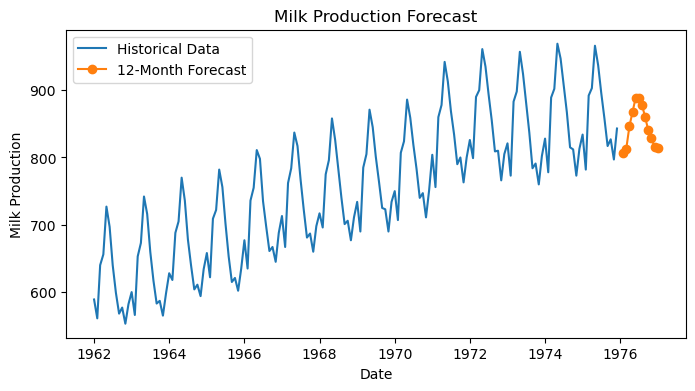

In [46]:
# Visualizing historical data and future forecast

future_dates = pd.date_range(
    start=data.index[-1],
    periods=13,
    freq='M'
)[1:]  # Skip the last historical date

plt.figure(figsize=(8, 4))
plt.plot(data.index, data['Production'], label='Historical Data')
plt.plot(future_dates, future_prediction, 
         label='12-Month Forecast', marker='o')

plt.title('Milk Production Forecast')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.show()

### Business Insights:

- LSTM and GRU demonstrate superior performance compared to the basic RNN due to their enhanced memory capabilities.

- The models effectively capture strong seasonal patterns in milk production.

- The forecast provides proactive visibility into future production trends, supporting better planning decisions.

### Recommendations

- Cold Storage Planning: Proactively adjust cold storage capacity based on forecasted production levels to prevent shortages or overutilization.

- Workforce Management: Optimize labor scheduling in alignment with anticipated production peaks and low-demand periods.

- Supply Chain Optimization: Synchronize transportation and distribution planning with projected production cycles to improve efficiency and reduce costs.